# Health Survey Data on Antenatal Care Providers in Kenya

## Background
The dataset originates from demographic and health surveys conducted in Kenya, focusing on healthcare service delivery, preferences, and outcomes over several decades. It includes data on indicators such as antenatal care providers, treatment of specific conditions, and the number of children born. The information is vital for understanding healthcare trends, resource allocation, and service quality across different regions and timeframes in Kenya.

## Objectives
1. **Examine trends and patterns in healthcare service delivery in Kenya.**

2. **Analyze resource efficiency and service preferences.**

3. **Identify gaps in healthcare provision to inform policymaking and resource optimization.**

## Research Questions
1. **How does the utilization of different types of antenatal care providers (e.g., doctors vs. nurses/midwives) vary across different regions in Kenya and over time?**
2.  **How has the percentage of women receiving antenatal care from different provider types changed from 1989 to 2022, and what factors may explain these trends?**
3.  **Are there significant geographical disparities in antenatal care provider utilization across urban and rural areas of Kenya?**
4.  **What are the perceived barriers to accessing antenatal care services among women in Kenya, and how do these barriers differ by region or socioeconomic status?**
5.  **How do the rates of antenatal care provider utilization in Kenya compare to those in other countries with similar demographic and health indicators?**

## Data Description
The dataset used in this analysis is the "access-to-health-care_national_ken dataset" from "data.humdata.org". It contains 1142 records, with features such ISO3, CountryName, DHS_CountryCode, Indicator, Value and Precision, SurveyYear and SurveyId, DenominatorWeighted, DenominatorUnweighted, Weighted_Ratio, and Preferred_Percentage. The dataset spans multiple years, offering both categorical and numerical insights, which are key for cross-sectional analysis.

## Methodology
The analysis will involve the following key steps:

1. **Data Cleaning:** Handled missing values, duplicates, outliers, and inconsitencies.

2. **Exploratory Data Analysis:** Visualized the distribution of indicators and analyzed trends across survey years.

3. **Feature Engineering:** Created new features such as Weighted_Ratio and Preferred_Percentage for deeper insights.
                            Applied transformations (e.g., logarithmic) to normalize skewed numerical data.

## Significance
The findings can guide policymakers in optimizing healthcare resource allocation and improving service delivery. Insights into service preferences can help tailor healthcare approaches to community needs so as to inform strategies for sustainable healthcare improvements.

## NON-TECHNICAL CONTENT
1. **Presentation [Link](https://docs.google.com/presentation/d/1zokURQf_vM1NNQa6K9JbogbgCE6KJFPQqSFZlEUbfDk/edit?usp=sharing)**
2. **Tableu [link](https://public.tableau.com/app/profile/ian.moire/viz/AntenatalCareAccessInsights/AntenatalCareAccessInsights)**

## Open the required libraries

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [112]:
# Open the dataset. Check the first five rows
df = pd.read_csv('/Users/mac/Documents/DATA.HUMDATA.ORG/access-to-health-care_national_ken.csv')
df.head()

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsPreferred,SDRID,RegionId,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,CILow,CIHigh,LevelRank
0,#country+code,#meta+id,#indicator+name,#indicator+value+num,#indicator+precision,NaN,#country+name,#date+year,#survey+id,#indicator+code,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEN,320356,Antenatal care provider: Doctor,29.4,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,0.0,RHANCPWDOC,NaN,1989,DHS,3559.0,3492.0,NaN,NaN,NaN
2,KEN,466928,Antenatal care provider: Doctor,30.1,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,0.0,RHANCPWDOC,NaN,1989,DHS,4237.0,4201.0,NaN,NaN,NaN
3,KEN,80479,Antenatal care provider: Doctor,29.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,1.0,RHANCPWDOC,NaN,1989,DHS,2701.0,2658.0,NaN,NaN,NaN
4,KEN,320341,Antenatal care provider: Nurse/midwife,48.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_NRS,...,0.0,RHANCPWNRS,NaN,1989,DHS,3559.0,3492.0,NaN,NaN,NaN


In [113]:
# Cheeck the last five rows
df.tail()

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsPreferred,SDRID,RegionId,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,CILow,CIHigh,LevelRank
1137,KEN,161263,Children with fever for whom advice or treatme...,1,1,KE,Kenya,2022,KE2022DHS,ML_FEVA_C_SHP,...,1.0,MLFEVACSHP,NaN,2022,DHS,2017.0,2174.0,NaN,NaN,NaN
1138,KEN,161273,Children with fever for whom advice or treatme...,0.5,1,KE,Kenya,2022,KE2022DHS,ML_FEVA_C_TRD,...,1.0,MLFEVACTRD,NaN,2022,DHS,2017.0,2174.0,NaN,NaN,NaN
1139,KEN,161274,Children with fever for whom advice or treatme...,0.4,1,KE,Kenya,2022,KE2022DHS,ML_FEVA_C_OTH,...,1.0,MLFEVACOTH,NaN,2022,DHS,2017.0,2174.0,NaN,NaN,NaN
1140,KEN,161291,Number of children under 5 with fever for whom...,2017,0,KE,Kenya,2022,KE2022DHS,ML_FEVA_C_NUM,...,1.0,MLFEVACNUM,NaN,2022,DHS,NaN,2174.0,NaN,NaN,NaN
1141,KEN,161290,Number of children under 5 with fever for whom...,2174,0,KE,Kenya,2022,KE2022DHS,ML_FEVA_C_UNW,...,1.0,MLFEVACUNW,NaN,2022,DHS,2017.0,NaN,NaN,NaN,NaN


In [114]:
# Determine the rows and the columns
df.shape

(1142, 29)

In [115]:
# Get the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1142 entries, 0 to 1141
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ISO3                    1142 non-null   object 
 1   DataId                  1142 non-null   object 
 2   Indicator               1142 non-null   object 
 3   Value                   1142 non-null   object 
 4   Precision               1142 non-null   object 
 5   DHS_CountryCode         1141 non-null   object 
 6   CountryName             1142 non-null   object 
 7   SurveyYear              1142 non-null   object 
 8   SurveyId                1142 non-null   object 
 9   IndicatorId             1142 non-null   object 
 10  IndicatorOrder          1141 non-null   float64
 11  IndicatorType           1141 non-null   object 
 12  CharacteristicId        1141 non-null   float64
 13  CharacteristicOrder     1141 non-null   float64
 14  CharacteristicCategory  1141 non-null   

In [116]:
# Check the summary of missing values in each column 
df.isna().sum()

ISO3                         0
DataId                       0
Indicator                    0
Value                        0
Precision                    0
DHS_CountryCode              1
CountryName                  0
SurveyYear                   0
SurveyId                     0
IndicatorId                  0
IndicatorOrder               1
IndicatorType                1
CharacteristicId             1
CharacteristicOrder          1
CharacteristicCategory       1
CharacteristicLabel          1
ByVariableId                 0
ByVariableLabel            238
IsTotal                      1
IsPreferred                  1
SDRID                        1
RegionId                  1142
SurveyYearLabel              1
SurveyType                   1
DenominatorWeighted        126
DenominatorUnweighted      126
CILow                     1142
CIHigh                    1142
LevelRank                 1142
dtype: int64

In [117]:
# Determine which rows and columns have missing values
df.isna()

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsPreferred,SDRID,RegionId,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,CILow,CIHigh,LevelRank
0,False,False,False,False,False,True,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
1138,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
1139,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
1140,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,True,True,True


In [118]:
# Determine the data types in the dataset
df.dtypes

ISO3                       object
DataId                     object
Indicator                  object
Value                      object
Precision                  object
DHS_CountryCode            object
CountryName                object
SurveyYear                 object
SurveyId                   object
IndicatorId                object
IndicatorOrder            float64
IndicatorType              object
CharacteristicId          float64
CharacteristicOrder       float64
CharacteristicCategory     object
CharacteristicLabel        object
ByVariableId               object
ByVariableLabel            object
IsTotal                   float64
IsPreferred               float64
SDRID                      object
RegionId                  float64
SurveyYearLabel            object
SurveyType                 object
DenominatorWeighted       float64
DenominatorUnweighted     float64
CILow                     float64
CIHigh                    float64
LevelRank                 float64
dtype: object

## Clean the Dataset by removing missing values

In [119]:
# List of columns to drop
columns_to_drop = ['RegionId', 'CILow', 'CIHigh', 'LevelRank']

# Drop these columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

# Verify the changes
print(df_cleaned.isna().sum())

ISO3                        0
DataId                      0
Indicator                   0
Value                       0
Precision                   0
DHS_CountryCode             1
CountryName                 0
SurveyYear                  0
SurveyId                    0
IndicatorId                 0
IndicatorOrder              1
IndicatorType               1
CharacteristicId            1
CharacteristicOrder         1
CharacteristicCategory      1
CharacteristicLabel         1
ByVariableId                0
ByVariableLabel           238
IsTotal                     1
IsPreferred                 1
SDRID                       1
SurveyYearLabel             1
SurveyType                  1
DenominatorWeighted       126
DenominatorUnweighted     126
dtype: int64


In [121]:
# Replace the missing values with the median for numerical columns
df_cleaned['DenominatorWeighted'].fillna(df_cleaned['DenominatorWeighted'].median(), inplace=True)
df_cleaned['DenominatorUnweighted'].fillna(df_cleaned['DenominatorUnweighted'].median(), inplace=True)

In [122]:
# Use a placeholder value for categorical columns
df_cleaned['IndicatorType'].fillna('Unknown', inplace=True)
df_cleaned['SurveyYearLabel'].fillna('Unknown', inplace=True)

In [123]:
# Fill the ByVariableLabel column with 'Not Specified'
df_cleaned['ByVariableLabel'].fillna('Not Specified', inplace=True)

In [124]:
# Check if the missing values were removed
print(df_cleaned.isna().sum())

ISO3                      0
DataId                    0
Indicator                 0
Value                     0
Precision                 0
DHS_CountryCode           1
CountryName               0
SurveyYear                0
SurveyId                  0
IndicatorId               0
IndicatorOrder            1
IndicatorType             0
CharacteristicId          1
CharacteristicOrder       1
CharacteristicCategory    1
CharacteristicLabel       1
ByVariableId              0
ByVariableLabel           0
IsTotal                   1
IsPreferred               1
SDRID                     1
SurveyYearLabel           0
SurveyType                1
DenominatorWeighted       0
DenominatorUnweighted     0
dtype: int64


In [125]:
# Fill the 'DHS_CountryCode' and 'SurveyType' with a placeholder
df_cleaned['DHS_CountryCode'].fillna('Unknown', inplace=True)
df_cleaned['SurveyType'].fillna('Unknown', inplace=True)

In [126]:
# Drop the 'CharacteristicId', 'CharacteristicLabel' that have NaN values
df_cleaned.dropna(subset=['CharacteristicId', 'CharacteristicLabel'], inplace=True)

In [127]:
# Recheck if the missing values were removed
print(df_cleaned.isna().sum())

ISO3                      0
DataId                    0
Indicator                 0
Value                     0
Precision                 0
DHS_CountryCode           0
CountryName               0
SurveyYear                0
SurveyId                  0
IndicatorId               0
IndicatorOrder            0
IndicatorType             0
CharacteristicId          0
CharacteristicOrder       0
CharacteristicCategory    0
CharacteristicLabel       0
ByVariableId              0
ByVariableLabel           0
IsTotal                   0
IsPreferred               0
SDRID                     0
SurveyYearLabel           0
SurveyType                0
DenominatorWeighted       0
DenominatorUnweighted     0
dtype: int64


In [130]:
# Check the dataset if there is a difference after being cleaned
df_cleaned.head()

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,CharacteristicLabel,ByVariableId,ByVariableLabel,IsTotal,IsPreferred,SDRID,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted
1,KEN,320356,Antenatal care provider: Doctor,29.4,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,Total,14000,Three years preceding the survey,1.0,0.0,RHANCPWDOC,1989,DHS,3559.0,3492.0
2,KEN,466928,Antenatal care provider: Doctor,30.1,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,Total,14001,Five years preceding the survey,1.0,0.0,RHANCPWDOC,1989,DHS,4237.0,4201.0
3,KEN,80479,Antenatal care provider: Doctor,29.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,Total,14002,Two years preceding the survey,1.0,1.0,RHANCPWDOC,1989,DHS,2701.0,2658.0
4,KEN,320341,Antenatal care provider: Nurse/midwife,48.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_NRS,...,Total,14000,Three years preceding the survey,1.0,0.0,RHANCPWNRS,1989,DHS,3559.0,3492.0
5,KEN,466932,Antenatal care provider: Nurse/midwife,47.9,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_NRS,...,Total,14001,Five years preceding the survey,1.0,0.0,RHANCPWNRS,1989,DHS,4237.0,4201.0


## Check for duplicates 

In [131]:
# Check if the dataset has duplicates
print(df_cleaned.duplicated().sum())

0


### NOTE: 
**The dataset has no duplicates**

## Check if the dataset has outliers

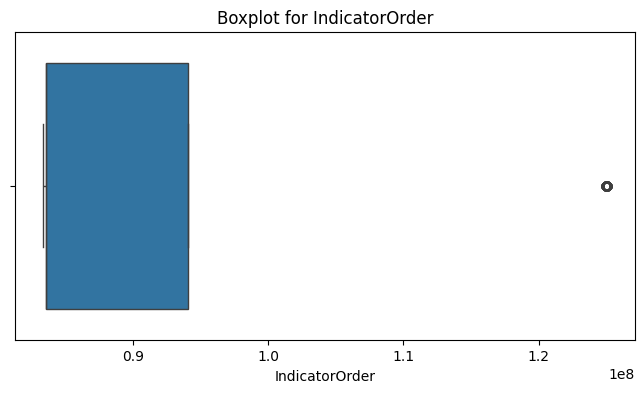

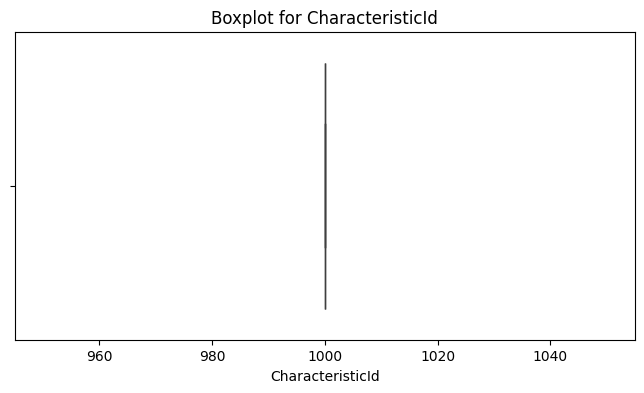

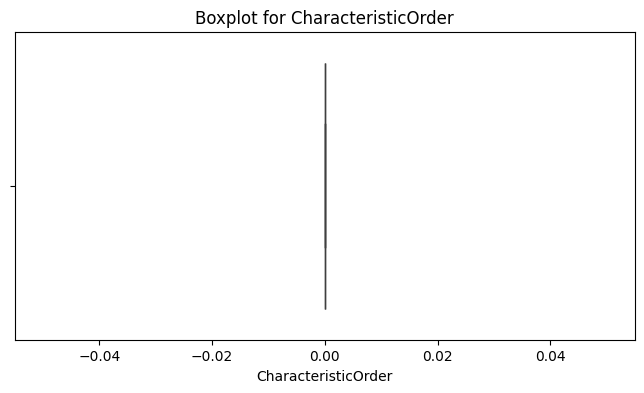

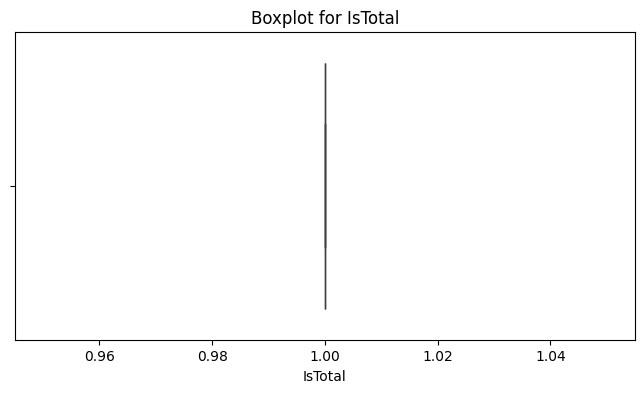

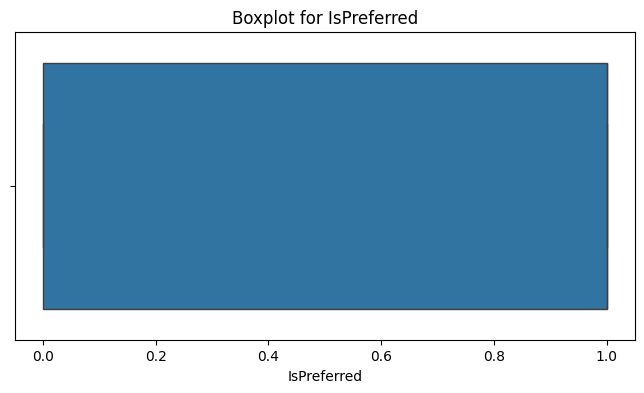

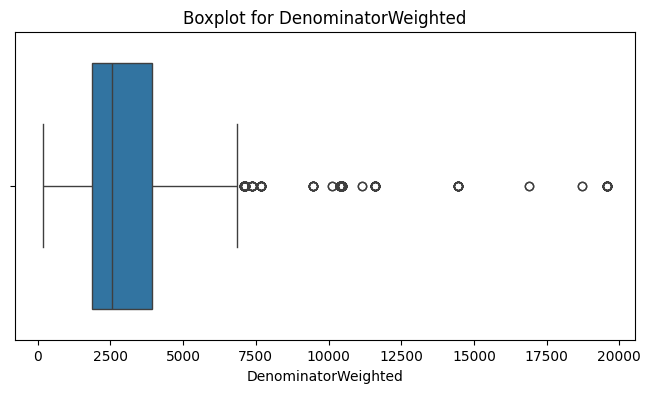

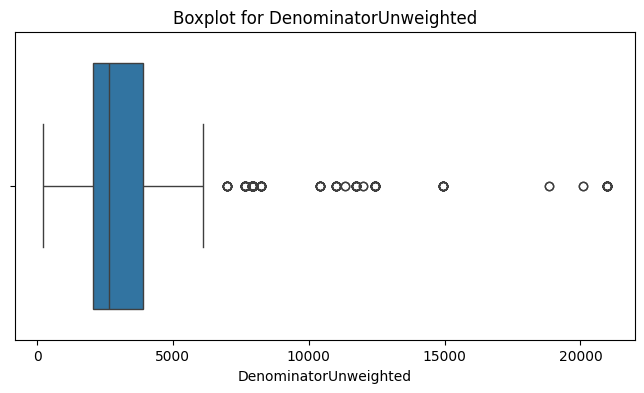

In [132]:
# Vusualise the distribution using boxplots
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_cleaned[column])
    plt.title(f'Boxplot for {column}')
    plt.show()

In [133]:
# Step 3: IQR-based outlier detection and removal
for column in numerical_columns:
    Q1 = df_cleaned[column].quantile(0.25)  # 25th percentile
    Q3 = df_cleaned[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1                           # Interquartile range

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Flag outliers
    outliers = (df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)
    print(f"Outliers in {column}:")
    print(df_cleaned[outliers])

    # Remove outliers
    df_cleaned = df_cleaned[~outliers]

print("\nDataset after outlier removal:")
print(df_cleaned)


Outliers in IndicatorOrder:
     ISO3  DataId                                          Indicator Value  \
428   KEN  612793  Children under 5 with fever for whom advice or...    29   
429   KEN  612794  Children under 5 with fever for whom advice or...   6.6   
430   KEN  612792  Children under 5 with fever for whom advice or...  10.3   
431   KEN  612799  Children under 5 with fever for whom advice or...  12.6   
432   KEN  612804  Children under 5 with fever for whom advice or...  32.3   
...   ...     ...                                                ...   ...   
1137  KEN  161263  Children with fever for whom advice or treatme...     1   
1138  KEN  161273  Children with fever for whom advice or treatme...   0.5   
1139  KEN  161274  Children with fever for whom advice or treatme...   0.4   
1140  KEN  161291  Number of children under 5 with fever for whom...  2017   
1141  KEN  161290  Number of children under 5 with fever for whom...  2174   

     Precision DHS_CountryCode Coun

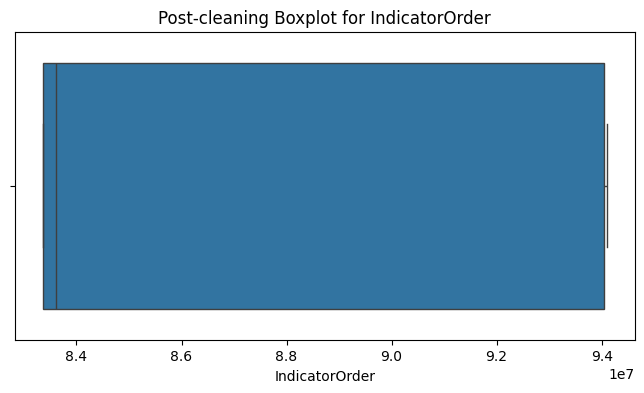

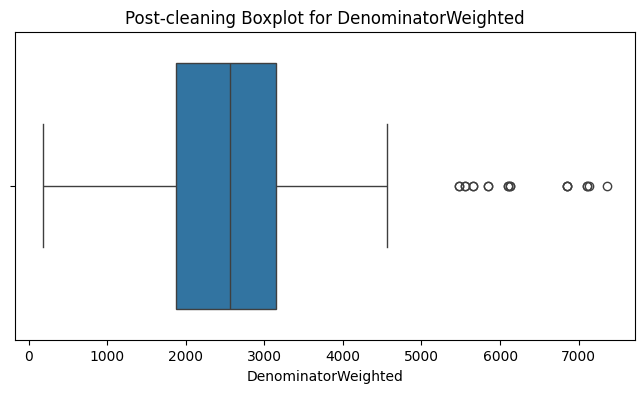

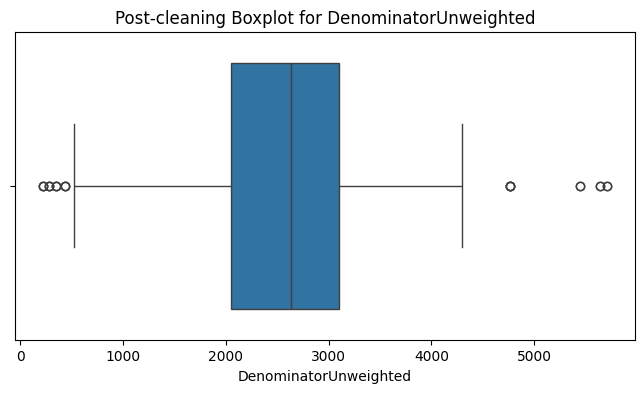

In [134]:
# To check if the outliers were removed
for column in ['IndicatorOrder', 'DenominatorWeighted', 'DenominatorUnweighted']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_cleaned[column])
    plt.title(f'Post-cleaning Boxplot for {column}')
    plt.show()

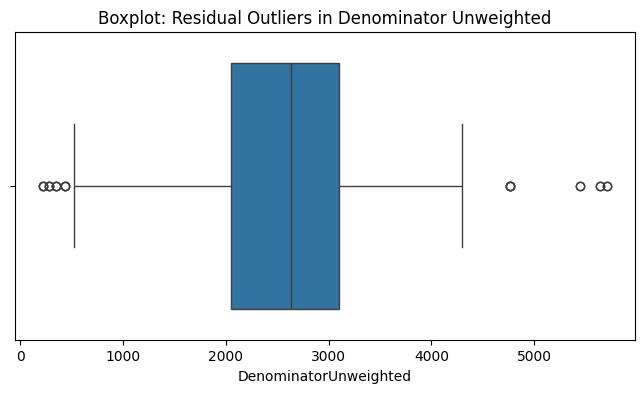

Residual outliers in DenominatorUnweighted:
     ISO3  DataId                                          Indicator Value  \
158   KEN  408127                      Children with symptoms of ARI  18.2   
160   KEN  136506  Number of children born in the last five (or t...  5650   
385   KEN  702409                      Children with symptoms of ARI  18.4   
387   KEN  703747  Number of children born in the last five (or t...  5560   
564   KEN  520786                      Children with symptoms of ARI   7.6   
566   KEN  529005  Number of children born in the last five (or t...  5481   
569   KEN  340133  Children with ARI for whom advice or treatment...  72.3   
570   KEN  701625  Children with ARI for whom advice or treatment...  69.9   
571   KEN  340119  Children with symptoms of ARI who received ant...  53.2   
572   KEN  701626  Children with symptoms of ARI who received ant...  49.6   
573   KEN  144288  Number of children with symptoms of ARI born i...   264   
574   KEN  701627  N

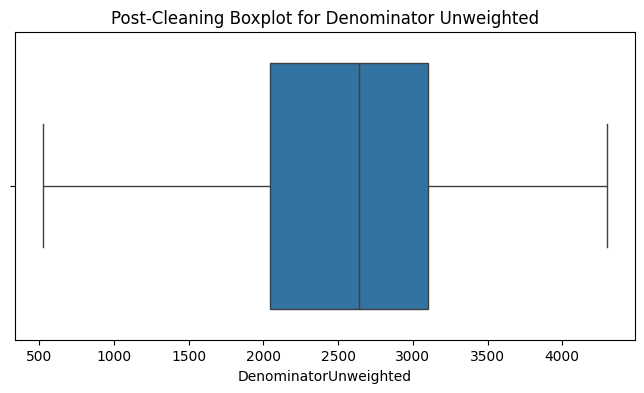

In [135]:
# Visualize residual outliers in Denominator Unweighted
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_cleaned['DenominatorUnweighted'])
plt.title('Boxplot: Residual Outliers in Denominator Unweighted')
plt.show()

# Reapply IQR method for Denominator Unweighted
column = 'DenominatorUnweighted'
Q1 = df_cleaned[column].quantile(0.25)  # 25th percentile
Q3 = df_cleaned[column].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1                           # Interquartile range

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag residual outliers
outliers = (df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)
print(f"Residual outliers in {column}:")
print(df_cleaned[outliers])

# Option 1: Remove the outliers
df_cleaned = df_cleaned[~outliers]

# Visualize after handling
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_cleaned[column])
plt.title('Post-Cleaning Boxplot for Denominator Unweighted')
plt.show()


## Exploratory Data Analysis

In [136]:
# Get the summary statistics of the dataset
df_cleaned.describe()

,IndicatorOrder,CharacteristicId,CharacteristicOrder,IsTotal,IsPreferred,DenominatorWeighted,DenominatorUnweighted
count,6.880000e+02,688.0,688.0,688.0,688.000000,688.000000,688.000000
mean,8.762363e+07,1000.0,0.0,1.0,0.457849,2490.454942,2464.441860
std,5.163254e+06,0.0,0.0,0.0,0.498583,1183.543957,997.979733
min,8.336301e+07,1000.0,0.0,1.0,0.000000,183.000000,524.000000
25%,8.336313e+07,1000.0,0.0,1.0,0.000000,1872.000000,2046.000000
50%,8.360610e+07,1000.0,0.0,1.0,0.000000,2521.000000,2637.000000
75%,9.403605e+07,1000.0,0.0,1.0,1.000000,3151.000000,3101.000000
max,9.409617e+07,1000.0,0.0,1.0,1.000000,7357.000000,4298.000000


### 1. Univariate Analysis

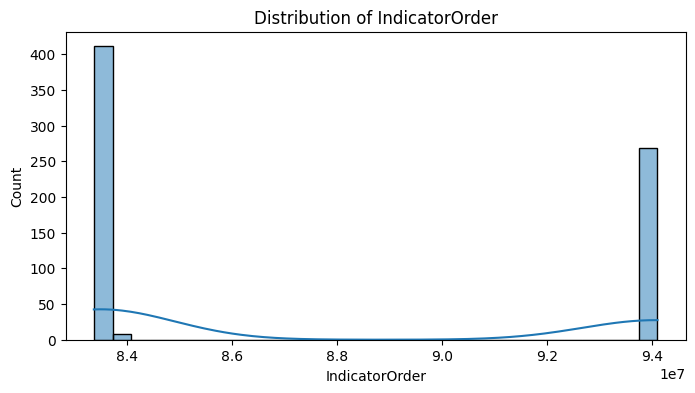

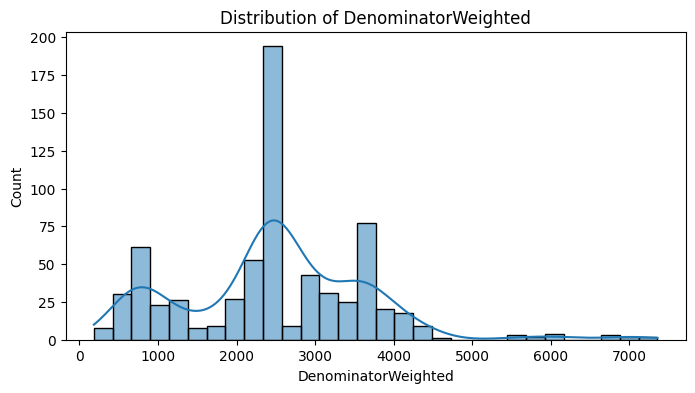

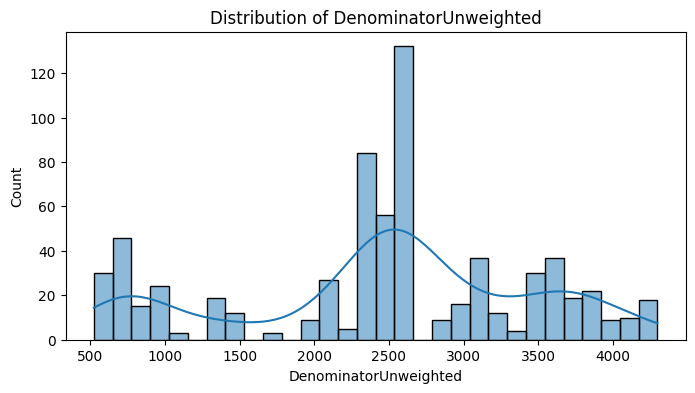

In [137]:
# Visualize the distributions of the numerical columns 
for column in ['IndicatorOrder', 'DenominatorWeighted', 'DenominatorUnweighted']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_cleaned[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.show()

### 2. Bivariate Analysis

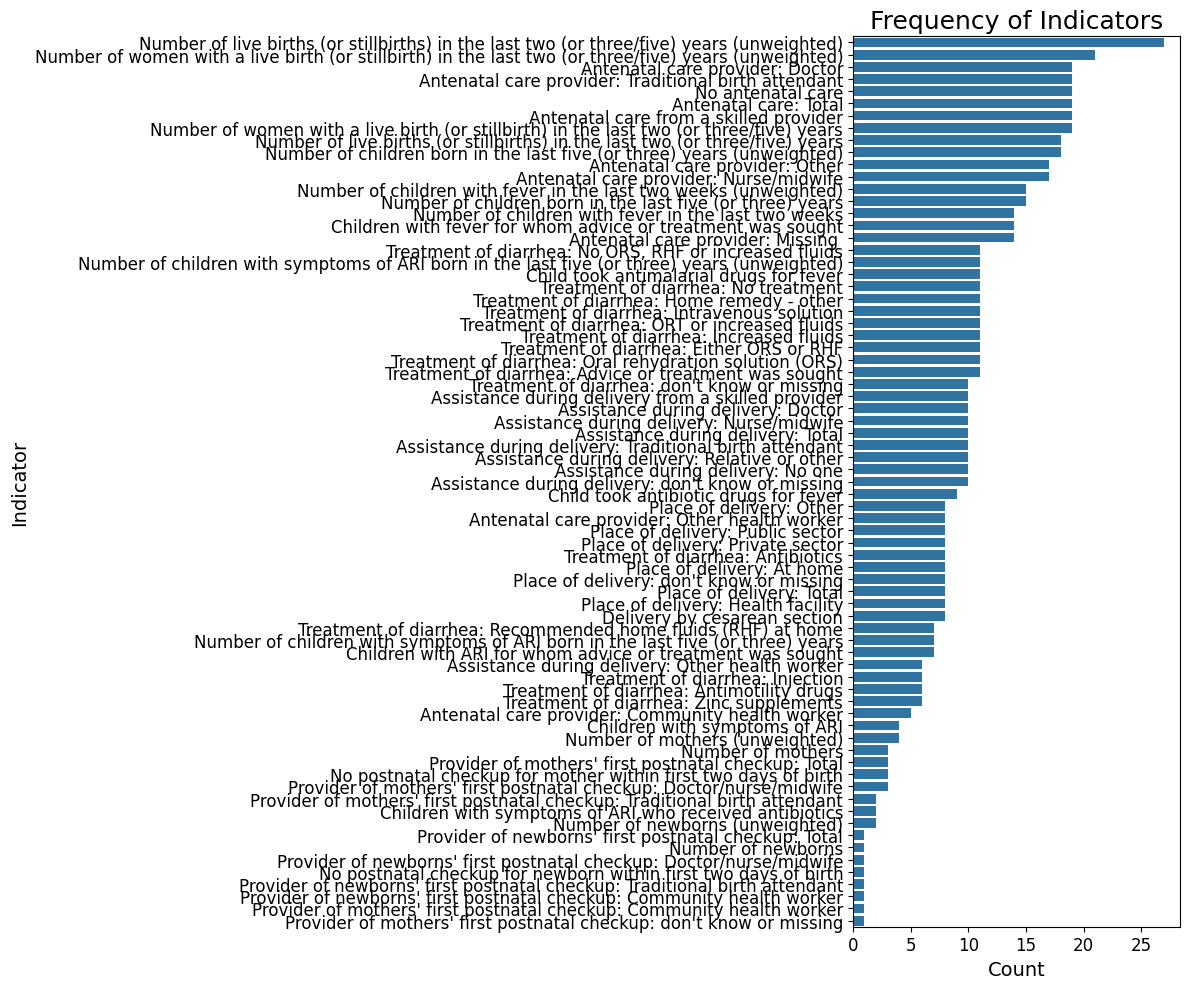

In [138]:
#  visualization of two variables
plt.figure(figsize=(12, 10))  
sns.countplot(y='Indicator', data=df_cleaned, order=df_cleaned['Indicator'].value_counts().index)

# Customize title, labels, and font sizes for clarity
plt.title('Frequency of Indicators', fontsize=18)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Indicator', fontsize=14)

# Increase space for y-axis labels and rotate them slightly if needed
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.tight_layout()  
plt.show()

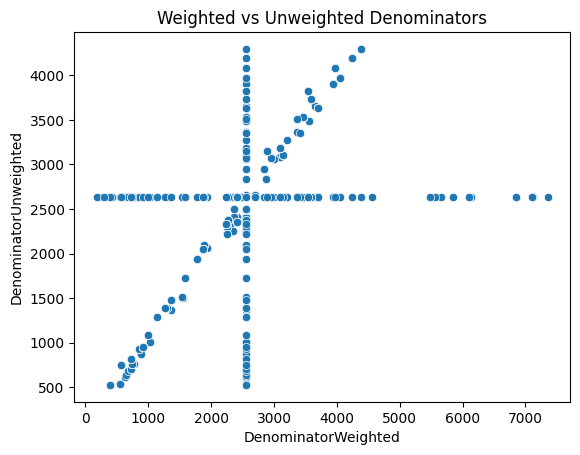

In [139]:
# Get the relationship between 'DenominatorWeighted' and 'DenominatorUnweighted variables'
sns.scatterplot(x='DenominatorWeighted', y='DenominatorUnweighted', data=df_cleaned)
plt.title('Weighted vs Unweighted Denominators')
plt.show()

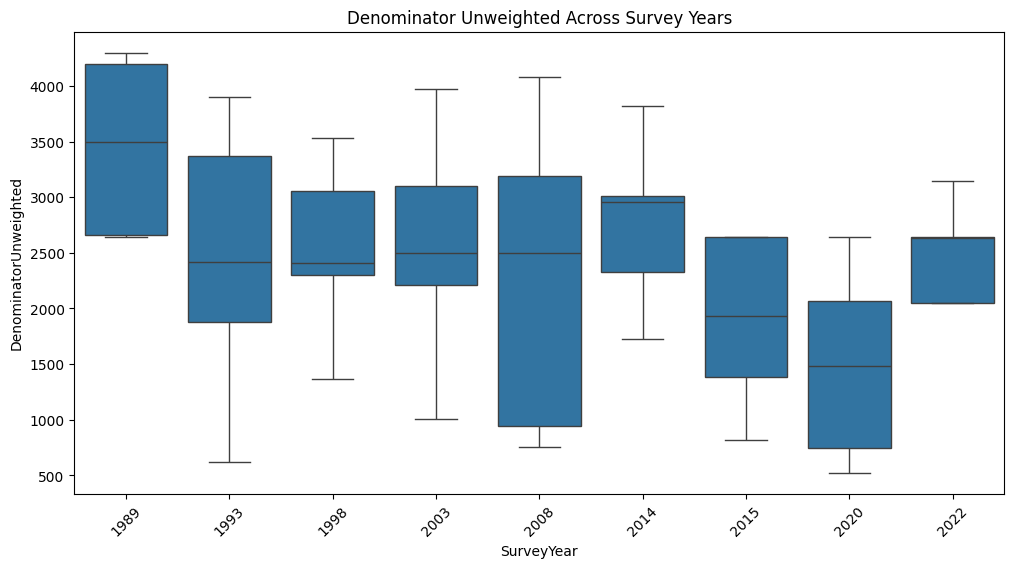

In [140]:
# Visulize the distribution between numerical and categorical columns
plt.figure(figsize=(12, 6))
sns.boxplot(x='SurveyYear', y='DenominatorUnweighted', data=df_cleaned, showfliers=False)
plt.title('Denominator Unweighted Across Survey Years')
plt.xticks(rotation=45)
plt.show()

### 3. Multivariate Analysis

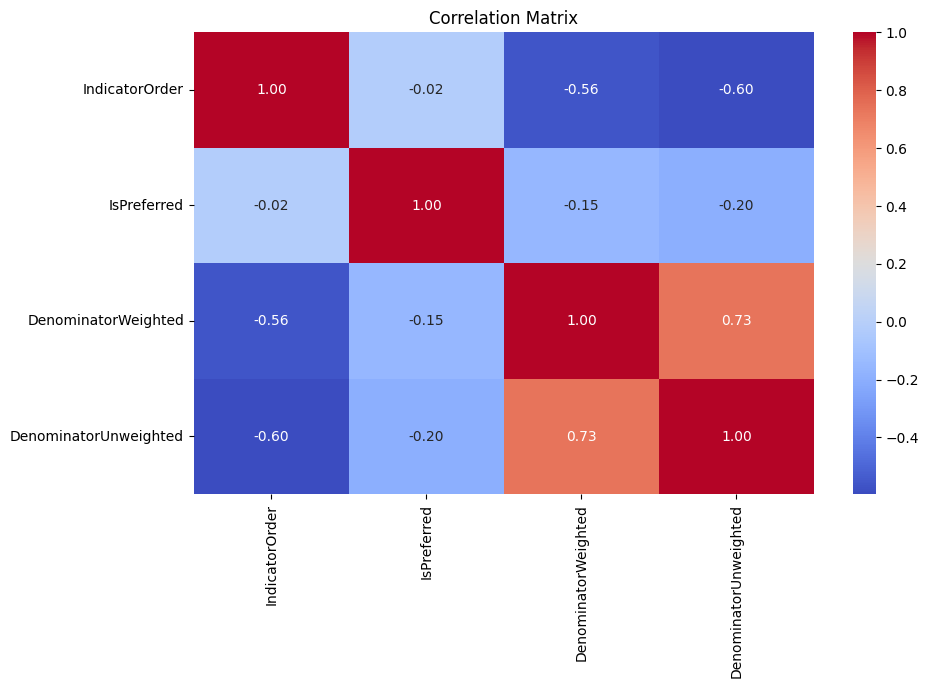

In [141]:
# Filter numerical columns only
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
numerical_data = df_cleaned[numerical_columns]

# Calculate the correlation matrix
corr_matrix = numerical_data.corr()

# Drop columns and rows with NaN values
corr_matrix = corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Feature Engineering

### 1. Creating new features

In [142]:
# The ratio of DenominatorWeighted to the DenominatorUnweighted
df_cleaned['Weighted_Ratio'] = df_cleaned['DenominatorWeighted'] / df_cleaned['DenominatorUnweighted']
df_cleaned['Weighted_Ratio']

1       1.019187
2       1.008569
3       1.016178
4       1.019187
5       1.008569
          ...   
1101    0.916193
1102    1.252199
1103    0.971559
1104    0.709360
1105    0.915498
Name: Weighted_Ratio, Length: 688, dtype: float64

In [143]:
# Get the percentage for IsPreferred
df_cleaned['Preferred_Percentage'] = df_cleaned['IsPreferred'] * 100
df_cleaned['Preferred_Percentage']

1         0.0
2         0.0
3       100.0
4         0.0
5         0.0
        ...  
1101    100.0
1102      0.0
1103    100.0
1104      0.0
1105    100.0
Name: Preferred_Percentage, Length: 688, dtype: float64

### 2. Applying Log Transformation to handle Skewed Data

In [144]:
# Log transformation example
df_cleaned['Log_DenominatorWeighted'] = np.log1p(df_cleaned['DenominatorWeighted'])
df_cleaned['Log_DenominatorWeighted']

1       8.177516
2       8.351847
3       7.901748
4       8.177516
5       8.351847
          ...   
1101    7.790282
1102    7.848934
1103    7.848934
1104    7.535297
1105    7.790282
Name: Log_DenominatorWeighted, Length: 688, dtype: float64

In [145]:
print(df_cleaned.isnull().sum())

ISO3                       0
DataId                     0
Indicator                  0
Value                      0
Precision                  0
DHS_CountryCode            0
CountryName                0
SurveyYear                 0
SurveyId                   0
IndicatorId                0
IndicatorOrder             0
IndicatorType              0
CharacteristicId           0
CharacteristicOrder        0
CharacteristicCategory     0
CharacteristicLabel        0
ByVariableId               0
ByVariableLabel            0
IsTotal                    0
IsPreferred                0
SDRID                      0
SurveyYearLabel            0
SurveyType                 0
DenominatorWeighted        0
DenominatorUnweighted      0
Weighted_Ratio             0
Preferred_Percentage       0
Log_DenominatorWeighted    0
dtype: int64


In [147]:
# Print the cleaned dataset
output_file_path = df_cleaned
output_file_path

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsTotal,IsPreferred,SDRID,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,Weighted_Ratio,Preferred_Percentage,Log_DenominatorWeighted
1,KEN,320356,Antenatal care provider: Doctor,29.4,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,1.0,0.0,RHANCPWDOC,1989,DHS,3559.0,3492.0,1.019187,0.0,8.177516
2,KEN,466928,Antenatal care provider: Doctor,30.1,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,1.0,0.0,RHANCPWDOC,1989,DHS,4237.0,4201.0,1.008569,0.0,8.351847
3,KEN,80479,Antenatal care provider: Doctor,29.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_DOC,...,1.0,1.0,RHANCPWDOC,1989,DHS,2701.0,2658.0,1.016178,100.0,7.901748
4,KEN,320341,Antenatal care provider: Nurse/midwife,48.6,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_NRS,...,1.0,0.0,RHANCPWNRS,1989,DHS,3559.0,3492.0,1.019187,0.0,8.177516
5,KEN,466932,Antenatal care provider: Nurse/midwife,47.9,1,KE,Kenya,1989,KE1989DHS,RH_ANCP_W_NRS,...,1.0,0.0,RHANCPWNRS,1989,DHS,4237.0,4201.0,1.008569,0.0,8.351847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,KEN,545103,Treatment of diarrhea: don't know or missing,0.2,1,KE,Kenya,2022,KE2022DHS,CH_DIAT_C_DKM,...,1.0,1.0,CHDIATCDKM,2022,DHS,2416.0,2637.0,0.916193,100.0,7.790282
1102,KEN,697702,Number of children born in the last five (or t...,1872,0,KE,Kenya,2022,KE2022DHS,CH_DIAT_C_NUM,...,1.0,0.0,CHDIATCNUM,2022,DHS,2562.0,2046.0,1.252199,0.0,7.848934
1103,KEN,550536,Number of children born in the last five (or t...,2416,0,KE,Kenya,2022,KE2022DHS,CH_DIAT_C_NUM,...,1.0,1.0,CHDIATCNUM,2022,DHS,2562.0,2637.0,0.971559,100.0,7.848934
1104,KEN,305719,Number of children born in the last five (or t...,2046,0,KE,Kenya,2022,KE2022DHS,CH_DIAT_C_UNW,...,1.0,0.0,CHDIATCUNW,2022,DHS,1872.0,2639.0,0.709360,0.0,7.535297


## Summary of key findings
Nurse/midwife care providers were frequently preferred in antenatal services, while preferences for doctors varied. The analysis reveals consistent improvements in healthcare service efficiency (Weighted Ratios) over decades. The Weighted Ratios generally indicate efficient resource allocation across healthcare indicators, with consistency observed in surveys over time.

## Implications
The data indicates varying percentages of antenatal care provider utilization (doctors vs. nurses/midwives). This information can guide policymakers in allocating resources efficiently to areas with higher needs or lower usage rates, potentially improving maternal health outcomes.

## Limitations
The dataset may not capture external factors affecting antenatal care utilization, such as cultural attitudes towards healthcare, economic barriers, and geographical access to medical facilities. Depending on the sample size and methodology of the Demographic and Health Surveys (DHS), the dataset may not fully represent all segments of the population, particularly rural versus urban differences.

## Future Work
Implement predictive modeling techniques to forecast future trends in antenatal care provider usage. This could help in proactive policy formulation and resource allocation. Consider expanding the analysis to include other healthcare indicators beyond antenatal care, such as maternal morbidity and mortality rates.


## References

## ***data.humdata.org***

***(https://data.humdata.org/dataset/dhs-data-for-kenya?force_layout=desktop)***

In [149]:
# Save the cleaned data to a csv file with the full path
output_file_path = 'cleaned_access-to-health-care_national_ken.csv'
df.to_csv(output_file_path, index=False)

print("Data saved successfully as cleaned_access-to-health-care_national_ken.csv.")

Data saved successfully as cleaned_access-to-health-care_national_ken.csv.
